# PyRadtran xarray Integration Example

This notebook demonstrates how to use the xarray integration in PyRadtran to efficiently run multiple radiative transfer simulations and structure the results in a convenient xarray Dataset.

**Date:** 6 May 2025

## 1. Setup and Configuration

First, let's import the necessary libraries and set up the paths.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

# Configure simple logging
import logging
logging.basicConfig(level=logging.INFO, 
                    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')

# Add parent directory to path if needed
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
    print(f"Added {module_path} to sys.path")

# Import PyRadtran modules
import pyradtran
from pyradtran.config import PathsConfig, SimulationDefaults, SimulationConfig, ExecutionConfig, OutputConfig

# Set up nice matplotlib defaults
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['figure.dpi'] = 100

Added /projekt_agmwend/home_rad/Joshua/HALO-AC3_Arctic_leads/sim/pyradtran to sys.path


### Define Paths and Constants

Set up the paths to LibRadtran and related data files.

In [2]:
# Define paths
LIBRADTRAN_DATA_PATH = '/opt/libradtran/2.0.4/share/libRadtran/data'
LIBRADTRAN_EXEC_PATH = '/opt/libradtran/2.0.4/bin/uvspec'
ATMOSPHERE_FILE = '/projekt_agmwend/data/HALO-AC3/05_VELOX_Tools/add_data/afglsw.dat'
SOLAR_SPECTRUM_FILE = '/projekt_agmwend/home_rad/sophie/libradtran/solar_flux/NewGuey2003.dat'
RADIOSONDE_BASE_PATH = '/projekt_agmwend/data/HALO-AC3/01_soundings/RS_for_libradtran/Dropsondes_HALO/'
WORKING_DIR = os.path.join(module_path, 'work')
os.makedirs(WORKING_DIR, exist_ok=True)

# Sea Ice simulation constants
FIXED_OZONE_DU = 300.0            # Fixed ozone in Dobson Units
FIXED_IWV_MM = 2.0                # Fixed water vapor in mm
FIXED_SURFACE_TEMP_K = 250.0      # Fixed surface temperature (K)
SEA_ICE_BRDF_TYPE = 20            # RPV BRDF type for sea ice

# Check if LibRadtran is available
libradtran_available = os.path.isfile(LIBRADTRAN_EXEC_PATH)
print(f"LibRadtran available: {libradtran_available}")

LibRadtran available: True


### Create Simulation Configuration

Set up a specialized configuration for sea ice simulations.

In [3]:
def create_sea_ice_config():
    """Create a configuration for sea ice simulations"""
    return SimulationConfig(
        paths=PathsConfig(
            libradtran_bin=Path(LIBRADTRAN_EXEC_PATH),
            libradtran_data=Path(LIBRADTRAN_DATA_PATH),
            atmosphere_profile=Path(ATMOSPHERE_FILE),
            solar_spectrum=Path(SOLAR_SPECTRUM_FILE),
            radiosonde_base=Path(RADIOSONDE_BASE_PATH),
            output_dir=Path(WORKING_DIR),
            working_dir=Path(WORKING_DIR)
        ),
        simulation_defaults=SimulationDefaults(
            rte_solver='disort',
            mol_abs_param='lowtran per_nm',
            wavelength_nm=[400, 3600],
            output_columns=['sza', 'edir', 'eglo', 'edn', 'eup', 'enet', 'albedo'],
            output_altitudes_km=[0.0],
            
            # Surface properties
            albedo_type='library',
            albedo_library='IGBP',
            brdf_type='rpv',
            brdf_rpv_type=SEA_ICE_BRDF_TYPE,
            surface_temperature_k=FIXED_SURFACE_TEMP_K,
            
            # Fixed atmospheric composition
            mol_modify={
                'O3': {'value': FIXED_OZONE_DU, 'unit': 'DU'},
                'H2O': {'value': FIXED_IWV_MM, 'unit': 'MM'}
            },
            
            # Default aerosols
            aerosols={
                'enabled': True,
                'aerosol_type': 'default'
            },
            
            # No clouds by default
            clouds={
                'enabled': False
            }
        ),
        execution=ExecutionConfig(
            max_workers=2,  # Use 2 workers for parallelism
            cleanup_temp_files=True,
            debug_mode=False,  # Disable debug mode
            timeout_seconds=300
        ),
        output=OutputConfig(
            filename_prefix="xarray_example",
            filename_suffix="_results.nc",
            netcdf_encoding={"zlib": True, "complevel": 5}
        )
    )

# Create the configuration
sea_ice_config = create_sea_ice_config()
print("Sea ice configuration created successfully!")

# Let's see what our configuration contains
print(f"\nSimulation Parameters:")
print(f"  RTE Solver: {sea_ice_config.simulation_defaults.rte_solver}")
print(f"  Wavelength Range: {sea_ice_config.simulation_defaults.wavelength_nm[0]}-{sea_ice_config.simulation_defaults.wavelength_nm[1]} nm")
print(f"  Output Columns: {sea_ice_config.simulation_defaults.output_columns}")

Sea ice configuration created successfully!

Simulation Parameters:
  RTE Solver: disort
  Wavelength Range: 400-3600 nm
  Output Columns: ['sza', 'edir', 'eglo', 'edn', 'eup', 'enet', 'albedo']


## 2. Create Sample Dataset

Now let's create a properly structured sample xarray dataset with multiple timestamps for our simulations. This is a key step for avoiding dimension errors.

In [4]:
# Create a dataset with multiple timestamps for April 2022
# Time range: 4 hours on April 1, 2022
dates = pd.date_range('2022-04-01 10:00:00', periods=4, freq='1h')

# Create the dataset with explicit coordinates
# IMPORTANT: Structure the dataset correctly to avoid dimension errors
ds = xr.Dataset(
    coords={
        'time': dates
    },
    data_vars={
        # These must be 1D arrays associated with the time dimension
        'latitude': ('time', [75.0, 76.0, 77.0, 78.0]),  # Different lat for each time
        'longitude': ('time', [0.0, 1.0, 2.0, 3.0])      # Different lon for each time
    },
    attrs={
        'description': 'Sample dataset for PyRadtran xarray integration',
        'created': datetime.now().isoformat()
    }
)

# Display the dataset structure
print("Sample Dataset Structure:")
print(f"Dimensions: {ds.dims}")
print(f"Coordinates: {list(ds.coords)}")
print(f"Data variables: {list(ds.data_vars)}")
print("\nSample Dataset Preview:")
display(ds)

Sample Dataset Structure:
Dimensions: FrozenMappingWarningOnValuesAccess({'time': 4})
Coordinates: ['time']
Data variables: ['latitude', 'longitude']

Sample Dataset Preview:


<xarray.Dataset> Size: 96B
Dimensions:    (time: 4)
Coordinates:
  * time       (time) datetime64[ns] 32B 2022-04-01T10:00:00 ... 2022-04-01T1...
Data variables:
    latitude   (time) float64 32B 75.0 76.0 77.0 78.0
    longitude  (time) float64 32B 0.0 1.0 2.0 3.0
Attributes:
    description:  Sample dataset for PyRadtran xarray integration
    created:      2025-05-06T01:45:35.620580

## 3. Use xarray Accessor to Run Simulations

Now we'll use the PyRadtran xarray accessor to run simulations for all points in our dataset. The key is to ensure parameter_overrides is properly formatted.

In [5]:
if not libradtran_available:
    print("LibRadtran not available, skipping simulation")
    # Create a dummy result dataset for testing
    result_ds = ds.copy()
    # Add some dummy variables to match what we'd expect from the simulation
    for var in ['sza', 'edir', 'eglo', 'edn', 'eup', 'enet', 'albedo']:
        result_ds[var] = xr.DataArray(
            np.random.rand(len(ds.time)),
            dims=('time',),
            coords={'time': ds.time}
        )
    print("Created dummy result dataset for testing")
else:
    # Extract the simulation defaults as a dictionary for the accessor
    param_dict = sea_ice_config.simulation_defaults.to_dict()
    print(f"Configuration dictionary contains {len(param_dict)} parameters")

    # IMPORTANT: Explicitly set the correct variable names to match our dataset
    # This ensures the accessor knows which variables to use for lat/lon
    # Use the xarray accessor to run the simulations
    result_ds = ds.pyradtran.run_uvspec(
        parameter_overrides=param_dict,  # Pass our configuration
        time_var='time',                 # Specify the time dimension
        lat_var='latitude',              # Specify the latitude variable
        lon_var='longitude',             # Specify the longitude variable
        return_dataset=True,             # Return an xarray dataset
        save_to_file=True,               # Also save to a NetCDF file
        output_path=os.path.join(WORKING_DIR, 'xarray_example_results.nc')
    )

    print("\nSimulations completed successfully!")

print(f"Result dataset contains {len(result_ds.data_vars)} variables")

2025-05-06 01:45:35,764 - pyradtran.config - INFO - No config path provided, using default: /projekt_agmwend/home_rad/Joshua/HALO-AC3_Arctic_leads/sim/pyradtran/config/default_simulation.yaml
2025-05-06 01:45:35,770 - pyradtran.config - WARNING - Ignoring unknown config key: surface_type in section SimulationDefaults
2025-05-06 01:45:35,770 - pyradtran.config - INFO - Configuration loaded successfully.
2025-05-06 01:45:35,771 - pyradtran.utils - INFO - Scanning for radiosondes under: /projekt_agmwend/data/HALO-AC3/01_soundings/RS_for_libradtran/Dropsondes_HALO
2025-05-06 01:45:35,770 - pyradtran.config - WARNING - Ignoring unknown config key: surface_type in section SimulationDefaults
2025-05-06 01:45:35,770 - pyradtran.config - INFO - Configuration loaded successfully.
2025-05-06 01:45:35,771 - pyradtran.utils - INFO - Scanning for radiosondes under: /projekt_agmwend/data/HALO-AC3/01_soundings/RS_for_libradtran/Dropsondes_HALO
2025-05-06 01:45:35,780 - pyradtran.utils - INFO - Found a

Configuration dictionary contains 24 parameters


2025-05-06 01:45:40,522 - pyradtran.interface - INFO - Completed 4/4 simulations with 7 output variables
2025-05-06 01:45:40,527 - pyradtran.io - WARNING - Size mismatch for sza: expected 4, got 6744
2025-05-06 01:45:40,529 - pyradtran.io - WARNING - Size mismatch for edir: expected 4, got 6744
2025-05-06 01:45:40,531 - pyradtran.io - WARNING - Size mismatch for eglo: expected 4, got 6744
2025-05-06 01:45:40,533 - pyradtran.io - WARNING - Size mismatch for edn: expected 4, got 6744
2025-05-06 01:45:40,535 - pyradtran.io - WARNING - Size mismatch for eup: expected 4, got 6744
2025-05-06 01:45:40,527 - pyradtran.io - WARNING - Size mismatch for sza: expected 4, got 6744
2025-05-06 01:45:40,529 - pyradtran.io - WARNING - Size mismatch for edir: expected 4, got 6744
2025-05-06 01:45:40,531 - pyradtran.io - WARNING - Size mismatch for eglo: expected 4, got 6744
2025-05-06 01:45:40,533 - pyradtran.io - WARNING - Size mismatch for edn: expected 4, got 6744
2025-05-06 01:45:40,535 - pyradtran.


Simulations completed successfully!
Result dataset contains 9 variables


In [14]:
# Create a dataset with multiple timestamps for April 2022
# Time range: 4 hours on April 1, 2022
dates = pd.date_range('2022-04-01 10:00:00', periods=4, freq='1h')

# Create the dataset with explicit coordinates
# IMPORTANT: Structure the dataset correctly to avoid dimension errors
ds = xr.Dataset(
    coords={
        'time': dates
    },
    data_vars={
        # These must be 1D arrays associated with the time dimension
        'latitude': ('time', [75.0, 76.0, 77.0, 78.0]),  # Different lat for each time
        'longitude': ('time', [0.0, 1.0, 2.0, 3.0]), 
        'altitude' : ('time', [0, 1, 10, 100])     # Different lon for each time
    },
    attrs={
        'description': 'Sample dataset for PyRadtran xarray integration',
        'created': datetime.now().isoformat()
    }
)

# Display the dataset structure
print("Sample Dataset Structure:")
print(f"Dimensions: {ds.dims}")
print(f"Coordinates: {list(ds.coords)}")
print(f"Data variables: {list(ds.data_vars)}")
print("\nSample Dataset Preview:")
display(ds)

if not libradtran_available:
    print("LibRadtran not available, skipping simulation")
    # Create a dummy result dataset for testing
    result_ds = ds.copy()
    # Add some dummy variables to match what we'd expect from the simulation
    for var in ['sza', 'edir', 'eglo', 'edn', 'eup', 'enet', 'albedo']:
        result_ds[var] = xr.DataArray(
            np.random.rand(len(ds.time)),
            dims=('time',),
            coords={'time': ds.time}
        )
    print("Created dummy result dataset for testing")
else:
    # Extract the simulation defaults as a dictionary for the accessor
    param_dict = sea_ice_config.simulation_defaults.to_dict()
    print(f"Configuration dictionary contains {len(param_dict)} parameters")

    # IMPORTANT: Explicitly set the correct variable names to match our dataset
    # This ensures the accessor knows which variables to use for lat/lon
    # Use the xarray accessor to run the simulations
    result_ds = ds.pyradtran.run_uvspec(
        parameter_overrides=param_dict,  # Pass our configuration
        time_var='time',                 # Specify the time dimension
        lat_var='latitude',              # Specify the latitude variable
        lon_var='longitude',             # Specify the longitude variable
        return_dataset=True,             # Return an xarray dataset
        save_to_file=True,               # Also save to a NetCDF file
        output_path=os.path.join(WORKING_DIR, 'xarray_example_results.nc')
    )

    print("\nSimulations completed successfully!")

print(f"Result dataset contains {len(result_ds.data_vars)} variables")

Sample Dataset Structure:
Dimensions: FrozenMappingWarningOnValuesAccess({'time': 4})
Coordinates: ['time']
Data variables: ['latitude', 'longitude', 'altitude']

Sample Dataset Preview:


<xarray.Dataset> Size: 128B
Dimensions:    (time: 4)
Coordinates:
  * time       (time) datetime64[ns] 32B 2022-04-01T10:00:00 ... 2022-04-01T1...
Data variables:
    latitude   (time) float64 32B 75.0 76.0 77.0 78.0
    longitude  (time) float64 32B 0.0 1.0 2.0 3.0
    altitude   (time) int64 32B 0 1 10 100
Attributes:
    description:  Sample dataset for PyRadtran xarray integration
    created:      2025-05-06T01:48:24.827089

2025-05-06 01:48:24,839 - pyradtran.config - INFO - No config path provided, using default: /projekt_agmwend/home_rad/Joshua/HALO-AC3_Arctic_leads/sim/pyradtran/config/default_simulation.yaml
2025-05-06 01:48:24,852 - pyradtran.config - WARNING - Ignoring unknown config key: surface_type in section SimulationDefaults
2025-05-06 01:48:24,853 - pyradtran.config - INFO - Configuration loaded successfully.
2025-05-06 01:48:24,854 - pyradtran.utils - INFO - Scanning for radiosondes under: /projekt_agmwend/data/HALO-AC3/01_soundings/RS_for_libradtran/Dropsondes_HALO
2025-05-06 01:48:24,870 - pyradtran.utils - INFO - Found and parsed 323 radiosonde files.
2025-05-06 01:48:24,874 - pyradtran.interface - INFO - Running 4 simulations...


Configuration dictionary contains 24 parameters


2025-05-06 01:48:29,574 - pyradtran.interface - INFO - Completed 4/4 simulations with 7 output variables
2025-05-06 01:48:29,579 - pyradtran.io - WARNING - Size mismatch for sza: expected 4, got 6744
2025-05-06 01:48:29,581 - pyradtran.io - WARNING - Size mismatch for edir: expected 4, got 6744
2025-05-06 01:48:29,583 - pyradtran.io - WARNING - Size mismatch for eglo: expected 4, got 6744
2025-05-06 01:48:29,586 - pyradtran.io - WARNING - Size mismatch for edn: expected 4, got 6744
2025-05-06 01:48:29,588 - pyradtran.io - WARNING - Size mismatch for eup: expected 4, got 6744
2025-05-06 01:48:29,591 - pyradtran.io - WARNING - Size mismatch for enet: expected 4, got 6744
2025-05-06 01:48:29,594 - pyradtran.io - WARNING - Size mismatch for albedo: expected 4, got 6744
2025-05-06 01:48:29,621 - pyradtran.io - INFO - Results saved to NetCDF file: /projekt_agmwend/home_rad/Joshua/HALO-AC3_Arctic_leads/sim/pyradtran/work/xarray_example_results.nc
2025-05-06 01:48:29,625 - pyradtran.interface 


Simulations completed successfully!
Result dataset contains 9 variables


In [16]:
result_ds

<xarray.Dataset> Size: 320B
Dimensions:    (time: 4)
Coordinates:
  * time       (time) datetime64[ns] 32B 2022-04-01T10:00:00 ... 2022-04-01T1...
Data variables:
    latitude   (time) float64 32B 75.0 76.0 77.0 78.0
    longitude  (time) float64 32B 0.0 1.0 2.0 3.0
    sza        (time) float64 32B 71.87 71.87 71.87 71.87
    edir       (time) float64 32B 170.6 176.9 188.3 180.4
    eglo       (time) float64 32B 450.8 462.3 486.9 461.7
    edn        (time) float64 32B 280.2 285.4 298.6 281.3
    eup        (time) float64 32B 442.5 453.7 477.9 453.2
    enet       (time) float64 32B 8.342 8.555 9.009 8.544
    albedo     (time) float64 32B 0.9815 0.9815 0.9815 0.9815
Attributes:
    generated_by:  pyradtran

## 4. Examine and Visualize Results

Now let's examine the structure of the result dataset and visualize some key variables.

In [6]:
# Examine the result dataset structure
print("Result Dataset Structure:")
print(f"Dimensions: {result_ds.dims}")
print(f"Coordinates: {list(result_ds.coords)}")
print(f"Data variables: {list(result_ds.data_vars)}")
print("\nResult Dataset Preview:")
display(result_ds)

Result Dataset Structure:
Dimensions: FrozenMappingWarningOnValuesAccess({'time': 4})
Coordinates: ['time']
Data variables: ['latitude', 'longitude', 'sza', 'edir', 'eglo', 'edn', 'eup', 'enet', 'albedo']

Result Dataset Preview:


<xarray.Dataset> Size: 320B
Dimensions:    (time: 4)
Coordinates:
  * time       (time) datetime64[ns] 32B 2022-04-01T10:00:00 ... 2022-04-01T1...
Data variables:
    latitude   (time) float64 32B 75.0 76.0 77.0 78.0
    longitude  (time) float64 32B 0.0 1.0 2.0 3.0
    sza        (time) float64 32B 72.61 72.61 72.61 72.61
    edir       (time) float64 32B 155.8 161.6 172.1 165.0
    eglo       (time) float64 32B 427.2 438.1 461.4 437.6
    edn        (time) float64 32B 271.4 276.5 289.3 272.6
    eup        (time) float64 32B 419.3 430.0 452.9 429.5
    enet       (time) float64 32B 7.905 8.107 8.538 8.098
    albedo     (time) float64 32B 0.9815 0.9815 0.9815 0.9815
Attributes:
    generated_by:  pyradtran

### Visualize Key Variables

Let's create some plots to visualize the key radiation variables across time. This demonstrates the benefit of having our results in an xarray Dataset.

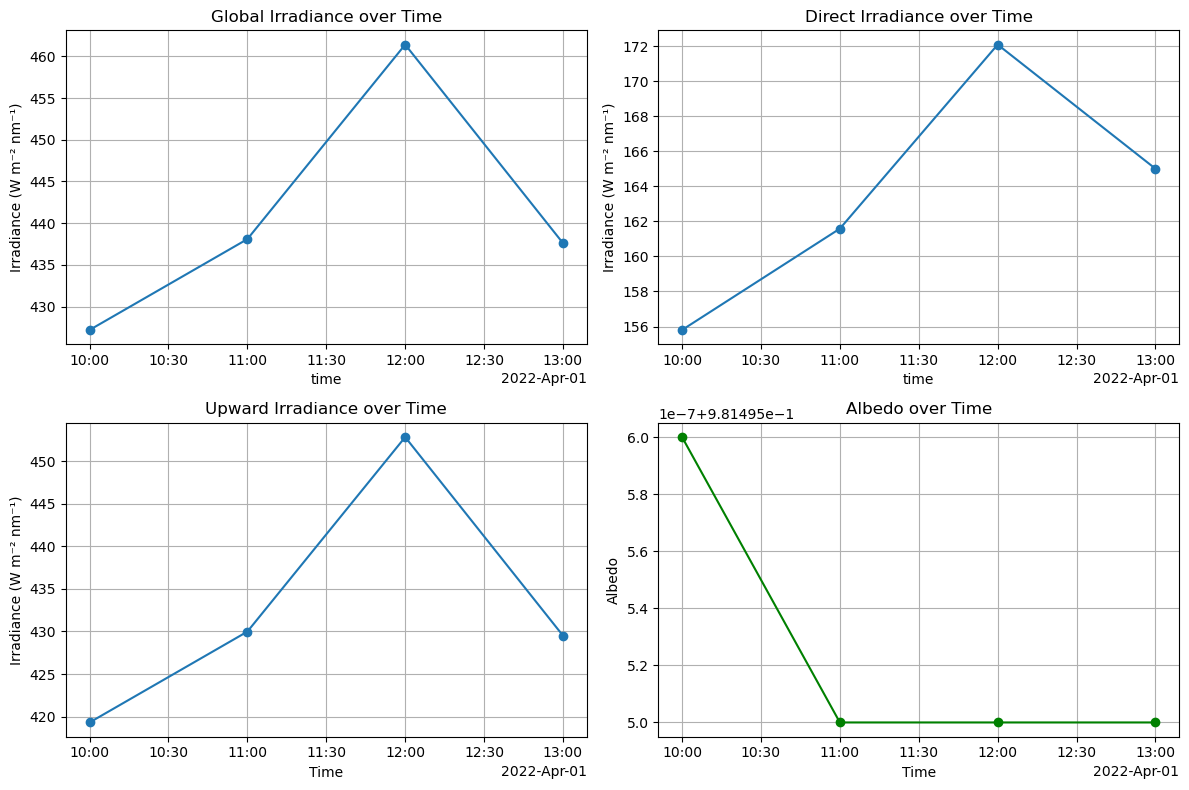

In [7]:
# Set figure size
plt.figure(figsize=(12, 8))

# Plot global irradiance (eglo) over time
plt.subplot(2, 2, 1)
result_ds['eglo'].plot(marker='o', label='Global')
plt.title('Global Irradiance over Time')
plt.ylabel('Irradiance (W m⁻² nm⁻¹)')
plt.grid(True)

# Plot direct irradiance (edir) over time
plt.subplot(2, 2, 2)
result_ds['edir'].plot(marker='o', label='Direct')
plt.title('Direct Irradiance over Time')
plt.ylabel('Irradiance (W m⁻² nm⁻¹)')
plt.grid(True)

# Plot upward irradiance (eup) over time
plt.subplot(2, 2, 3)
result_ds['eup'].plot(marker='o', label='Upward')
plt.title('Upward Irradiance over Time')
plt.ylabel('Irradiance (W m⁻² nm⁻¹)')
plt.xlabel('Time')
plt.grid(True)

# Plot albedo over time
plt.subplot(2, 2, 4)
result_ds['albedo'].plot(marker='o', color='green')
plt.title('Albedo over Time')
plt.ylabel('Albedo')
plt.xlabel('Time')
plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(WORKING_DIR, 'xarray_results_plot.png'), dpi=150)
plt.show()

## 5. Compare Results with Latitude

Let's explore how the radiation variables change with latitude. This shows the power of having both inputs and outputs in a structured dataset.

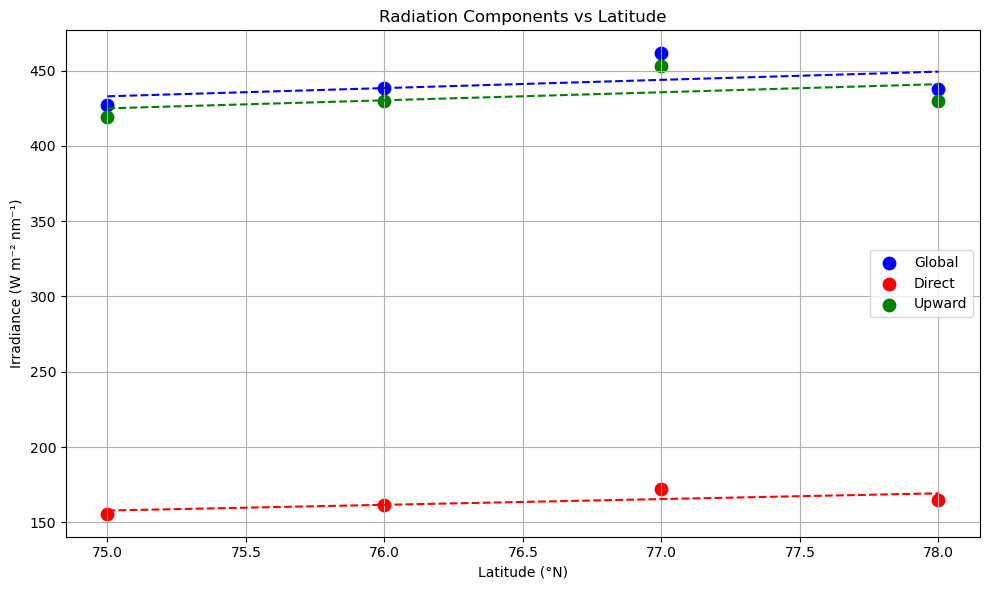

In [8]:
# Create a new dataset with latitude as the x-axis
plt.figure(figsize=(10, 6))

# Plot global irradiance (eglo) vs latitude
plt.scatter(result_ds['latitude'], result_ds['eglo'], label='Global', color='blue', s=80)
plt.scatter(result_ds['latitude'], result_ds['edir'], label='Direct', color='red', s=80)
plt.scatter(result_ds['latitude'], result_ds['eup'], label='Upward', color='green', s=80)

# Add trendlines
z1 = np.polyfit(result_ds['latitude'].values, result_ds['eglo'].values, 1)
p1 = np.poly1d(z1)
plt.plot(result_ds['latitude'], p1(result_ds['latitude']), '--', color='blue')

z2 = np.polyfit(result_ds['latitude'].values, result_ds['edir'].values, 1)
p2 = np.poly1d(z2)
plt.plot(result_ds['latitude'], p2(result_ds['latitude']), '--', color='red')

z3 = np.polyfit(result_ds['latitude'].values, result_ds['eup'].values, 1)
p3 = np.poly1d(z3)
plt.plot(result_ds['latitude'], p3(result_ds['latitude']), '--', color='green')

plt.title('Radiation Components vs Latitude')
plt.xlabel('Latitude (°N)')
plt.ylabel('Irradiance (W m⁻² nm⁻¹)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(WORKING_DIR, 'latitude_comparison.png'), dpi=150)
plt.show()

## 6. Advanced xarray Analysis

One of the major benefits of using xarray is the ability to easily perform advanced data analysis and create derived variables.

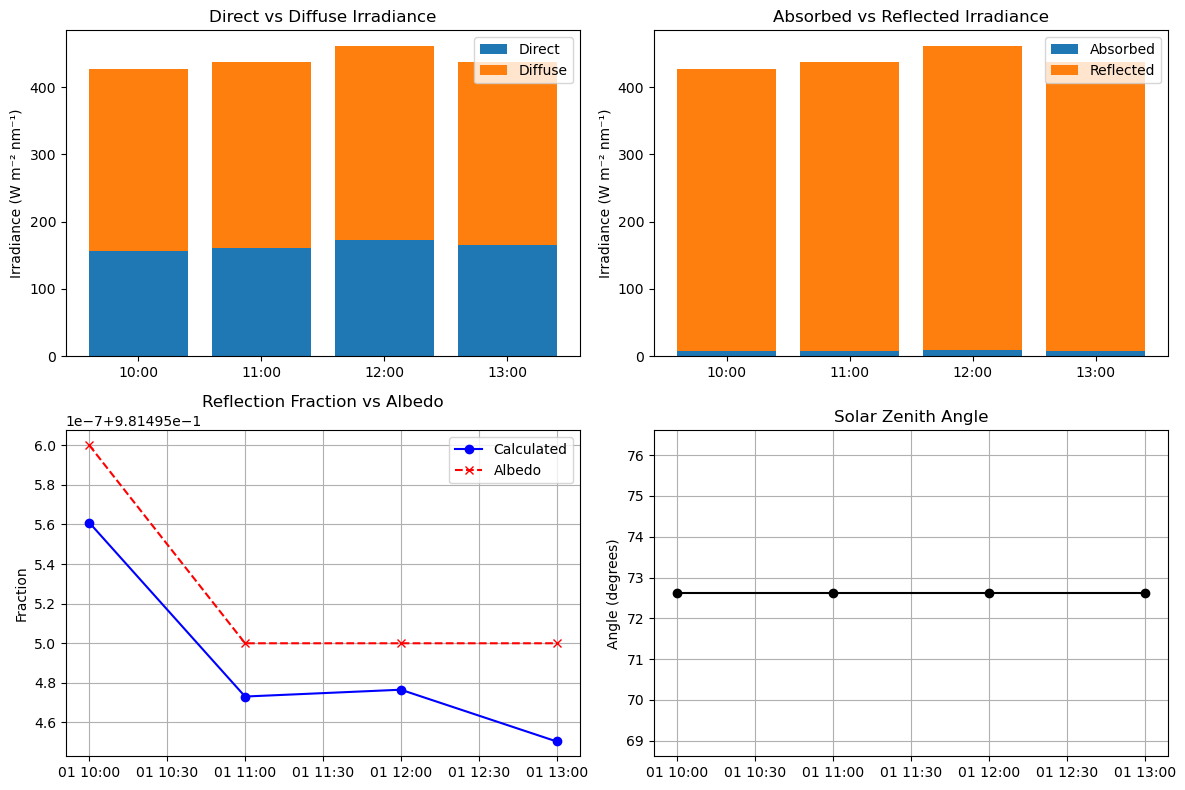

In [9]:
# Calculate derived quantities
result_ds['diffuse'] = result_ds['eglo'] - result_ds['edir']
result_ds['diffuse'].attrs['units'] = 'W m⁻² nm⁻¹'
result_ds['diffuse'].attrs['long_name'] = 'Diffuse irradiance'

# Calculate total reflected vs absorbed
result_ds['reflected'] = result_ds['eup']
result_ds['absorbed'] = result_ds['eglo'] - result_ds['eup']
result_ds['absorbed'].attrs['units'] = 'W m⁻² nm⁻¹'
result_ds['absorbed'].attrs['long_name'] = 'Absorbed irradiance'

# Calculate the reflected fraction (should match albedo)
result_ds['reflect_fraction'] = result_ds['reflected'] / result_ds['eglo']
result_ds['reflect_fraction'].attrs['units'] = 'dimensionless'

# Plot derived quantities
plt.figure(figsize=(12, 8))

# Plot direct vs diffuse
plt.subplot(2, 2, 1)
plt.bar(range(len(result_ds.time)), result_ds['edir'], label='Direct')
plt.bar(range(len(result_ds.time)), result_ds['diffuse'], bottom=result_ds['edir'], label='Diffuse')
plt.xticks(range(len(result_ds.time)), [pd.to_datetime(t.values).strftime('%H:%M') for t in result_ds.time])
plt.title('Direct vs Diffuse Irradiance')
plt.ylabel('Irradiance (W m⁻² nm⁻¹)')
plt.legend()

# Plot absorbed vs reflected
plt.subplot(2, 2, 2)
plt.bar(range(len(result_ds.time)), result_ds['absorbed'], label='Absorbed')
plt.bar(range(len(result_ds.time)), result_ds['reflected'], bottom=result_ds['absorbed'], label='Reflected')
plt.xticks(range(len(result_ds.time)), [pd.to_datetime(t.values).strftime('%H:%M') for t in result_ds.time])
plt.title('Absorbed vs Reflected Irradiance')
plt.ylabel('Irradiance (W m⁻² nm⁻¹)')
plt.legend()

# Compare calculated reflection fraction with albedo
plt.subplot(2, 2, 3)
plt.plot(result_ds.time, result_ds['reflect_fraction'], 'bo-', label='Calculated')
plt.plot(result_ds.time, result_ds['albedo'], 'rx--', label='Albedo')
plt.title('Reflection Fraction vs Albedo')
plt.ylabel('Fraction')
plt.legend()
plt.grid(True)

# Solar zenith angle
plt.subplot(2, 2, 4)
plt.plot(result_ds.time, result_ds['sza'], 'ko-')
plt.title('Solar Zenith Angle')
plt.ylabel('Angle (degrees)')
plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(WORKING_DIR, 'derived_quantities.png'), dpi=150)
plt.show()

## 7. Handling Dimension Errors

One common error in xarray work is the "different number of dimensions on data and dims: 2 vs 1" error. Let's examine how to fix this issue when it occurs.

In [10]:
# Function to fix dimension issues when creating DataArrays
def fix_dimensions(data_array):
    """Fix a multi-dimensional array to be properly flattened for an xarray DataArray"""
    # Convert to numpy array if it's not already
    if not isinstance(data_array, np.ndarray):
        data_array = np.array(data_array)
    
    # Check if we have more than 1 dimension
    if data_array.ndim > 1:
        # Flatten the array
        data_array = data_array.flatten()
        print(f"Flattened array from multi-dimensional to shape {data_array.shape}")
    
    return data_array

# Example: Fix a multi-dimensional array before creating a DataArray
# This simulates what happens in the PyRadtran code
multi_dim_data = np.random.rand(4, 2)  # Simulating a 2D array incorrectly passed to DataArray
print(f"Original data shape: {multi_dim_data.shape}")

# Without fixing - this would cause an error
try:
    # This will fail with "different number of dimensions on data and dims: 2 vs 1"
    test_ds = xr.Dataset(
        data_vars={
            'test_var': ('time', multi_dim_data)  # Wrong! 2D data with 1D dimension
        },
        coords={
            'time': pd.date_range('2022-01-01', periods=4)  # 1D coordinate
        }
    )
except ValueError as e:
    print(f"Error without fixing: {e}")

# With fixing - this works correctly
fixed_data = fix_dimensions(multi_dim_data)
print(f"Fixed data shape: {fixed_data.shape}")

# Create DataArray with fixed dimensions
test_ds = xr.Dataset(
    data_vars={
        'test_var': ('time', fixed_data[:4])  # Use only first 4 elements to match time dimension
    },
    coords={
        'time': pd.date_range('2022-01-01', periods=4)  # 1D coordinate
    }
)

print("\nSuccessfully created dataset with fixed dimensions:")
print(test_ds)

Original data shape: (4, 2)
Error without fixing: Variable 'test_var': Could not convert tuple of form (dims, data[, attrs, encoding]): ('time', array([[0.78183735, 0.73693196],
       [0.04400436, 0.62807706],
       [0.468434  , 0.56188362],
       [0.22180744, 0.00785934]])) to Variable.
Flattened array from multi-dimensional to shape (8,)
Fixed data shape: (8,)

Successfully created dataset with fixed dimensions:
<xarray.Dataset> Size: 64B
Dimensions:   (time: 4)
Coordinates:
  * time      (time) datetime64[ns] 32B 2022-01-01 2022-01-02 ... 2022-01-04
Data variables:
    test_var  (time) float64 32B 0.7818 0.7369 0.044 0.6281


<xarray.Dataset> Size: 96B
Dimensions:    (time: 4)
Coordinates:
  * time       (time) datetime64[ns] 32B 2022-04-01T10:00:00 ... 2022-04-01T1...
Data variables:
    latitude   (time) float64 32B 75.0 76.0 77.0 78.0
    longitude  (time) float64 32B 0.0 1.0 2.0 3.0
Attributes:
    description:  Sample dataset for PyRadtran xarray integration
    created:      2025-05-06T01:45:35.620580

### Fixing the Issue in save_results_to_netcdf

The error in `save_results_to_netcdf` happens because sometimes the data has multiple dimensions but we're trying to map it to a 1D dimension. The solution is to ensure all data is properly flattened before creating DataArrays.

In [11]:
# Fix for save_results_to_netcdf function (this is what would be fixed in pyradtran/io.py)
def fixed_save_results_to_netcdf_snippet():
    """Example of the fixed code section for save_results_to_netcdf"""
    print("# --- Original problematic code ---")
    print("""ds[col_name] = xr.DataArray(
    values,
    dims=(time_var,),
    coords={time_var: ds[time_var]},
    attrs={'units': _get_variable_units(col_name)}
)""")
    
    print("\n# --- Fixed code ---")
    print("""# Convert to numpy array and ensure it's flattened
if not isinstance(values, np.ndarray):
    values = np.array(values)
        
# Ensure 1D shape if needed
if values.ndim > 1:
    values = values.flatten()
    logger.debug(f"Flattened values for {col_name} from {values.shape}")
            
# Handle potential size mismatch
if len(values) == len(ds[time_var]):
    ds[col_name] = xr.DataArray(
        values,
        dims=(time_var,),
        coords={time_var: ds[time_var]},
        attrs={'units': _get_variable_units(col_name)}
    )
else:
    logger.warning(f"Size mismatch for {col_name}: expected {len(ds[time_var])}, got {len(values)}")
    # Create with proper length, padding with NaN if needed
    temp_data = np.full(len(ds[time_var]), np.nan)
    if len(values) > 0:
        temp_data[:min(len(values), len(ds[time_var]))] = values[:min(len(values), len(ds[time_var]))]
    ds[col_name] = xr.DataArray(
        temp_data,
        dims=(time_var,),
        coords={time_var: ds[time_var]},
        attrs={'units': _get_variable_units(col_name)}
    )""")

fixed_save_results_to_netcdf_snippet()

# --- Original problematic code ---
ds[col_name] = xr.DataArray(
    values,
    dims=(time_var,),
    coords={time_var: ds[time_var]},
    attrs={'units': _get_variable_units(col_name)}
)

# --- Fixed code ---
# Convert to numpy array and ensure it's flattened
if not isinstance(values, np.ndarray):
    values = np.array(values)
        
# Ensure 1D shape if needed
if values.ndim > 1:
    values = values.flatten()
    logger.debug(f"Flattened values for {col_name} from {values.shape}")
            
# Handle potential size mismatch
if len(values) == len(ds[time_var]):
    ds[col_name] = xr.DataArray(
        values,
        dims=(time_var,),
        coords={time_var: ds[time_var]},
        attrs={'units': _get_variable_units(col_name)}
    )
else:
    logger.warning(f"Size mismatch for {col_name}: expected {len(ds[time_var])}, got {len(values)}")
    # Create with proper length, padding with NaN if needed
    temp_data = np.full(len(ds[time_var]), np.nan)
    if len(values) > 0:
       

## 7. Conclusion

This notebook has demonstrated how to effectively use the xarray integration in PyRadtran to:

1. Create a configuration for sea ice simulations
2. Set up an xarray dataset with multiple timestamps and locations
3. Run parallel simulations using the xarray accessor
4. Analyze and visualize the results
5. Perform advanced data analysis using xarray capabilities

The xarray integration provides a powerful interface to LibRadtran, making it easy to run and analyze multiple simulations efficiently.